In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import binom

np.random.seed(42)
sns.set_style("whitegrid")

Task 1: Monte Carlo π Estimation
Estimated π: 3.14412
True π:      3.14159
Difference:  0.00253



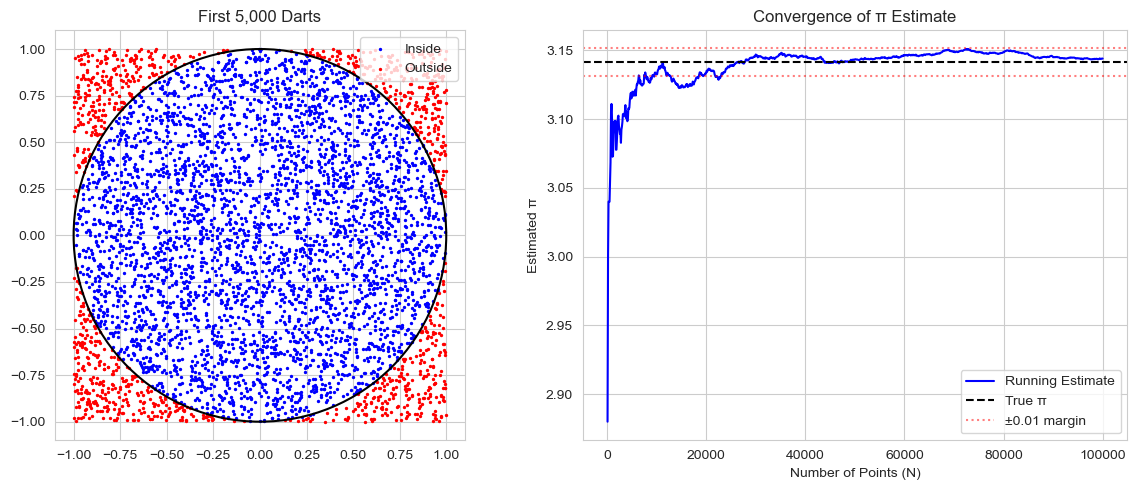

In [ ]:
# 1. Generate N = 100,000 random (x, y) points
N = 100000
x = np.random.uniform(-1, 1, N)
y = np.random.uniform(-1, 1, N)

# 2. Classify points inside the unit circle
inside = (x**2 + y**2) <= 1

# 3. Estimate π
pi_estimate = 4 * np.sum(inside) / N

# 4. Print estimate vs true value
print(f"Estimated π: {pi_estimate:.5f}")
print(f"True π:      {np.pi:.5f}")
print(f"Difference:  {abs(pi_estimate - np.pi):.5f}\n")

# 5. Scatter plot of the first 5,000 points
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
N_scatter = 5000
plt.scatter(x[:N_scatter][inside[:N_scatter]], y[:N_scatter][inside[:N_scatter]], 
            color='blue', s=2, label='Inside')
plt.scatter(x[:N_scatter][~inside[:N_scatter]], y[:N_scatter][~inside[:N_scatter]], 
            color='red', s=2, label='Outside')

# Draw the unit circle
circle = plt.Circle((0, 0), 1, color='black', fill=False, linewidth=1.5)
plt.gca().add_patch(circle)
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.gca().set_aspect('equal', adjustable='box')
plt.title("First 5,000 Darts")
plt.legend(loc='upper right')

# 6. Convergence plot
plt.subplot(1, 2, 2)
# Calculate running estimate for all N, then slice to get every 100th point
running_pi = 4 * np.cumsum(inside) / np.arange(1, N + 1)
steps = np.arange(100, N + 1, 100)
pi_steps = running_pi[steps - 1]

plt.plot(steps, pi_steps, label='Running Estimate', color='blue')
plt.axhline(np.pi, color='black', linestyle='--', label='True π')
plt.axhline(np.pi + 0.01, color='red', linestyle=':', alpha=0.5)
plt.axhline(np.pi - 0.01, color='red', linestyle=':', alpha=0.5, label='±0.01 margin')

plt.title("Convergence of π Estimate")
plt.xlabel("Number of Points (N)")
plt.ylabel("Estimated π")
plt.legend()
plt.tight_layout()
plt.show()

after 20000 sample

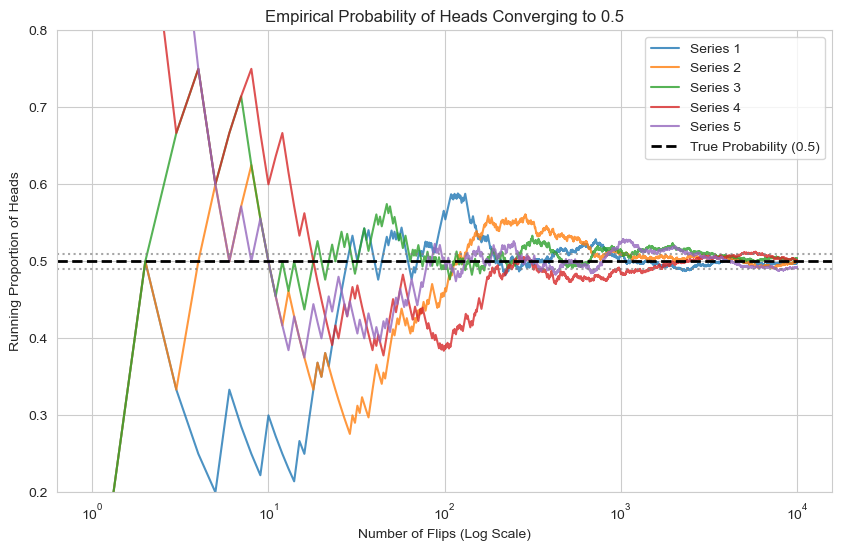

In [6]:
# Setup for the plot
plt.figure(figsize=(10, 6))

# 4. Repeat experiment 5 times
for i in range(5):
    # 1. Simulate 10,000 fair coin flips
    flips = np.random.choice([0, 1], size=10000)
    
    # 2. Compute the running proportion of heads
    running_prop = np.cumsum(flips) / np.arange(1, 10001)
    
    # 3. Plot the running proportion (log-scaled x-axis)
    plt.plot(np.arange(1, 10001), running_prop, alpha=0.8, label=f'Series {i+1}')

# Add reference lines
plt.axhline(0.5, color='black', linestyle='--', linewidth=2, label='True Probability (0.5)')
plt.axhline(0.51, color='gray', linestyle=':', alpha=0.7)
plt.axhline(0.49, color='gray', linestyle=':', alpha=0.7)

plt.xscale('log')
plt.ylim(0.2, 0.8)
plt.title("Empirical Probability of Heads Converging to 0.5")
plt.xlabel("Number of Flips (Log Scale)")
plt.ylabel("Running Proportion of Heads")
plt.legend()
plt.show()

approximately somewhere between 10^1 and 10^2(nearly 70-80)

Task 3: Binomial Simulation Results
Metric                    | Empirical  | Theoretical
--------------------------------------------------
P(0 defects)              | 0.21890    | 0.21807   
P(3 or more defects)      | 0.18910    | 0.18920   
Expected defects (Mean)   | 1.49630    | 1.50000   



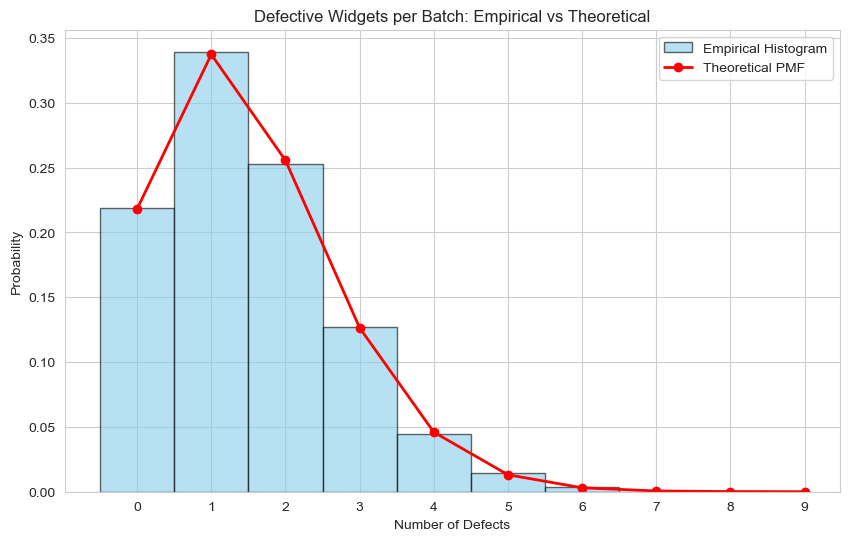

In [ ]:
n = 50
p = 0.03
n_batches = 10000

# 1. Simulate 10,000 batches
batches = np.random.binomial(n, p, size=n_batches)

# 2. Record/extract counts is handled natively by the numpy array 'batches'

# 4. Calculate Empirical Estimates
emp_0 = np.mean(batches == 0)
emp_3_or_more = np.mean(batches >= 3)
emp_mean = np.mean(batches)

# Theoretical Values
theo_0 = binom.pmf(0, n, p)
theo_3_or_more = 1 - binom.cdf(2, n, p)
theo_mean = n * p

print(f"{'Metric':<25} | {'Empirical':<10} | {'Theoretical':<10}")
print("-" * 50)
print(f"{'P(0 defects)':<25} | {emp_0:<10.5f} | {theo_0:<10.5f}")
print(f"{'P(3 or more defects)':<25} | {emp_3_or_more:<10.5f} | {theo_3_or_more:<10.5f}")
print(f"{'Expected defects (Mean)':<25} | {emp_mean:<10.5f} | {theo_mean:<10.5f}\n")

# 3. Plot Histogram vs Theoretical PMF
plt.figure(figsize=(10, 6))

# Histogram (Density=True normalizes it so the area sums to 1)
# Bins are aligned to integer values representing defect counts
bins = np.arange(-0.5, max(batches) + 1.5, 1)
plt.hist(batches, bins=bins, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Empirical Histogram')

# Overlay Theoretical PMF
k_vals = np.arange(0, max(batches) + 2)
pmf_vals = binom.pmf(k_vals, n, p)
plt.plot(k_vals, pmf_vals, marker='o', color='red', linestyle='-', linewidth=2, label='Theoretical PMF')

plt.title("Defective Widgets per Batch: Empirical vs Theoretical")
plt.xlabel("Number of Defects")
plt.ylabel("Probability")
plt.xticks(np.arange(0, max(batches) + 2))
plt.legend()
plt.show()

empirical estimates are close enough to theoreticals. 1000 batches would be enough for estimating mean or smh but it would struggle to estimates rarer events